# Template 05: Model Training

**Purpose:** Train XGBoost model and generate predictions

**Inputs:**
- data/04_train.parquet
- data/04_test.parquet

**Outputs:**
- models/xgb_model.json
- results/05_metrics.yaml
- results/05_predictions.parquet

In [1]:
config_path = "config/car_coll/v1"

In [2]:
# Parameters
config_path = "config/car_coll/v1"


In [3]:
import matplotlib
matplotlib.use('Agg')  # Non-interactive backend for papermill

import pandas as pd
import numpy as np
import xgboost as xgb
import yaml
import os
import sys
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error

sys.path.insert(0, str(Path.cwd() / 'lib'))
from utils import setup_notebook_environment

print("########################################")
print("# STAGE 05: MODEL TRAINING")
print("########################################")

project_root = setup_notebook_environment()

########################################
# STAGE 05: MODEL TRAINING
########################################


In [4]:
print(f"Python: {sys.version}")
print(f"XGBoost: {xgb.__version__}")


Python: 3.11.15 (main, Jun 11 2026, 15:14:57) [Clang 20.1.8 ]
XGBoost: 3.1.1


In [5]:
config_file = f"{config_path}/config.yaml"
with open(config_file, 'r') as f:
    cfg = yaml.safe_load(f)

output_base = cfg['paths']['output_base']
target = cfg['experiment']['target']
exposure = cfg['experiment']['exposure']

In [6]:
# Load train/test data
train = pd.read_parquet(f"{output_base}/data/04_train.parquet")
test = pd.read_parquet(f"{output_base}/data/04_test.parquet")

# Validate critical columns exist
critical_cols = [target, exposure]
missing = [c for c in critical_cols if c not in train.columns]
if missing:
    raise ValueError(f"Missing critical columns in train data: {missing}")

print(f"\n* Train: {train.shape}")
print(f"* Test: {test.shape}")


* Train: (2716120, 112)
* Test: (2707950, 112)


In [7]:
# Load feature list
features_df = pd.read_csv(f"{config_path}/{cfg['features']['inclusion_file']}", comment='#')
feature_cols = features_df['column_name'].tolist()

# Filter to available features
available_features = [f for f in feature_cols if f in train.columns]
print(f"\n* Features: {len(available_features)}/{len(feature_cols)} available")

X_train = train[available_features]
y_train = train[target]
X_test = test[available_features]
y_test = test[target]


* Features: 90/90 available


In [8]:
# Train XGBoost model
print(f"\n* Training XGBoost...")

xgb_params = cfg['xgboost'].copy()
n_estimators = xgb_params.pop('n_estimators')

# Construct full eval_metric for tweedie if needed
if 'eval_metric' in xgb_params and 'tweedie' in xgb_params['eval_metric']:
    if '@' not in xgb_params['eval_metric']:
        variance_power = xgb_params['tweedie_variance_power']
        xgb_params['eval_metric'] = f"{xgb_params['eval_metric']}@{variance_power}"

model = xgb.XGBRegressor(n_estimators=n_estimators, **xgb_params)
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100
)

print(f"\n* Model trained")
print(f"* Best iteration: {model.best_iteration}")


* Training XGBoost...


[0]	validation_0-tweedie-nloglik@1.5:59.01956	validation_1-tweedie-nloglik@1.5:61.99708


[88]	validation_0-tweedie-nloglik@1.5:54.37865	validation_1-tweedie-nloglik@1.5:60.86712



* Model trained
* Best iteration: 39


In [9]:
# Save training history
results = model.evals_result()
metric_base = cfg['xgboost']['eval_metric']

# Construct full metric name for tweedie if needed
if 'tweedie' in metric_base and '@' not in metric_base:
    variance_power = cfg['xgboost']['tweedie_variance_power']
    metric = f"{metric_base}@{variance_power}"
else:
    metric = metric_base

# Use exact metric from results
result_key = list(results['validation_0'].keys())[0]

history_df = pd.DataFrame({
    'iteration': range(len(results['validation_0'][result_key])),
    f'train_{metric}': results['validation_0'][result_key],
    f'test_{metric}': results['validation_1'][result_key]
})

history_file = f"{output_base}/results/05_training_history.parquet"
history_df.to_parquet(history_file, index=False)
print(f"\n* Training history saved: {history_file}")
print(f"  Total iterations: {len(history_df)}")
print(f"  Metric: {metric}")
print(f"  Final train {metric}: {history_df[f'train_{metric}'].iloc[-1]:.4f}")
print(f"  Final test {metric}: {history_df[f'test_{metric}'].iloc[-1]:.4f}")


* Training history saved: output/car_coll/v1/results/05_training_history.parquet
  Total iterations: 90
  Metric: tweedie-nloglik@1.5
  Final train tweedie-nloglik@1.5: 54.3540
  Final test tweedie-nloglik@1.5: 60.8672



* Learning curve saved: output/car_coll/v1/plots/05_learning_curve.png


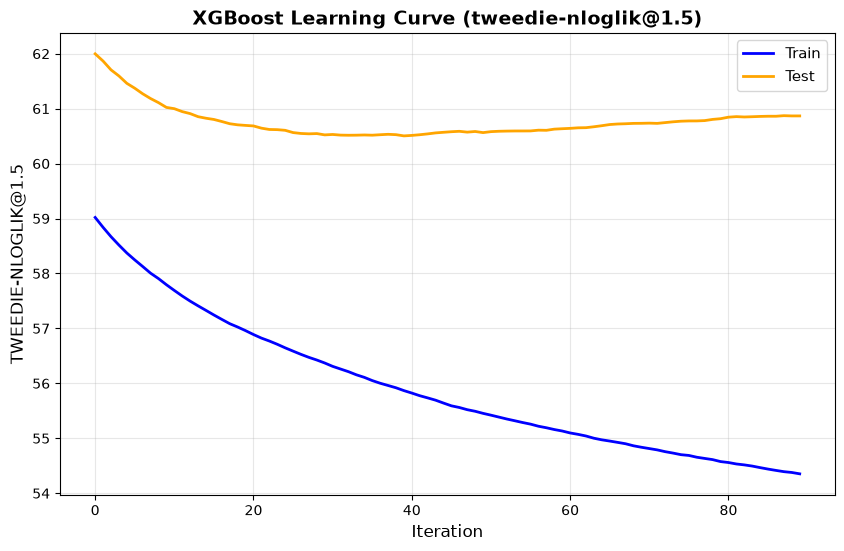

In [10]:
# Plot learning curve
from utils import plot_learning_curve
from IPython.display import Image, display

plot_path = plot_learning_curve(history_df, f"{output_base}/plots/05_learning_curve.png", metric=metric)
print(f"\n* Learning curve saved: {plot_path}")

# Display inline
display(Image(filename=plot_path))

In [11]:
# Predictions
train['pred'] = model.predict(X_train)
test['pred'] = model.predict(X_test)

# Metrics
train_mae = mean_absolute_error(y_train, train['pred'])
test_mae = mean_absolute_error(y_test, test['pred'])
train_rmse = np.sqrt(mean_squared_error(y_train, train['pred']))
test_rmse = np.sqrt(mean_squared_error(y_test, test['pred']))

print(f"\n* Metrics:")
print(f"  Train MAE: {train_mae:.4f}")
print(f"  Test MAE: {test_mae:.4f}")
print(f"  Train RMSE: {train_rmse:.4f}")
print(f"  Test RMSE: {test_rmse:.4f}")


* Metrics:
  Train MAE: 419.8382
  Test MAE: 441.4095
  Train RMSE: 15172.6537
  Test RMSE: 25138.7201


In [12]:
# Save model
model_file = f"{output_base}/models/xgb_model.json"
os.makedirs(f"{output_base}/models", exist_ok=True)
model.get_booster().save_model(model_file)
print(f"\n* Model saved: {model_file}")


* Model saved: output/car_coll/v1/models/xgb_model.json


In [13]:
# Save metrics
metrics = {
    'train_mae': float(train_mae),
    'test_mae': float(test_mae),
    'train_rmse': float(train_rmse),
    'test_rmse': float(test_rmse),
    'n_features': len(available_features),
    'train_size': len(train),
    'test_size': len(test)
}

metrics_file = f"{output_base}/results/05_metrics.yaml"
with open(metrics_file, 'w') as f:
    yaml.dump(metrics, f)

print(f"* Metrics saved: {metrics_file}")

* Metrics saved: output/car_coll/v1/results/05_metrics.yaml


In [14]:
# Save predictions separately for train and test
# Train predictions
train_pred = train[[target, exposure, 'pred']].copy()
train_pred.columns = ['actual', 'exposure', 'pred']

# Validate predictions output
required_cols = ['actual', 'exposure', 'pred']
missing = [c for c in required_cols if c not in train_pred.columns]
if missing:
    raise ValueError(f"[Stage 05] Missing prediction columns: {missing}")

train_pred_file = f"{output_base}/results/05_predictions_train.parquet"
train_pred.to_parquet(train_pred_file)

# Test predictions
test_pred = test[[target, exposure, 'pred']].copy()
test_pred.columns = ['actual', 'exposure', 'pred']
test_pred_file = f"{output_base}/results/05_predictions_test.parquet"
test_pred.to_parquet(test_pred_file)

print(f"* Train predictions saved: {train_pred_file}")
print(f"* Test predictions saved: {test_pred_file}")
print(f"[Stage 05 Output] ✓ Prediction columns validated: {', '.join(required_cols)}")

* Train predictions saved: output/car_coll/v1/results/05_predictions_train.parquet
* Test predictions saved: output/car_coll/v1/results/05_predictions_test.parquet
[Stage 05 Output] ✓ Prediction columns validated: actual, exposure, pred


## Lift Charts

In [15]:
# Prepare data for lift charts
# Get exposure column from config, or use fallback logic
exposure_col = cfg['experiment'].get('exposure', None)

if exposure_col and exposure_col in train.columns:
    weight_col = exposure_col
    print(f"\n* Using '{exposure_col}' from config as weight column")
elif 'ee' in train.columns:
    weight_col = 'ee'
    print(f"\n* Using 'ee' (earned exposure) as weight column")
elif 'ee_imps' in train.columns:
    weight_col = 'ee_imps'
    print(f"\n* Using 'ee_imps' (earned exposure imputed) as weight column")
else:
    train['weight'] = 1  # Equal weight per record
    test['weight'] = 1
    weight_col = 'weight'
    print(f"\n* WARNING: No exposure column found, using equal weighting (weight=1)")
    if exposure_col:
        print(f"  Config specifies '{exposure_col}' but it's not in the data!")

# Create incurred/denom columns for lift chart
# Use exposure as denominator if available
if weight_col in train.columns and weight_col != 'weight':
    train['incurred_act'] = train[target]
    train['incurred_pred'] = train['pred']
    train['denom'] = train[weight_col]  # Use exposure as denominator
    
    test['incurred_act'] = test[target]
    test['incurred_pred'] = test['pred']
    test['denom'] = test[weight_col]
else:
    train['incurred_act'] = train[target]
    train['incurred_pred'] = train['pred']
    train['denom'] = 1  # Equal weight
    
    test['incurred_act'] = test[target]
    test['incurred_pred'] = test['pred']
    test['denom'] = 1

print(f"* Prepared data for lift charts (weight_col='{weight_col}')")


* Using 'ee_bi_imps' from config as weight column
* Prepared data for lift charts (weight_col='ee_bi_imps')


In [16]:
# Load optimized lift chart function
import matplotlib.pyplot as plt
from lift_chart_fast import create_lift_chart

print("* Optimized lift chart function loaded")

* Optimized lift chart function loaded


In [17]:
print("\n* Generating train lift chart...")



* Generating train lift chart...


In [18]:
fig_train, table_train = create_lift_chart(train, weight_col, bins=10, title="Train Lift Chart")

  [STEP 1] Creating column list...
  [STEP 1] Done in 0.000s
  [STEP 2] Extracting 5 columns from 2,716,120 rows...
  [STEP 2] Done in 0.027s
  [STEP 3a] Sorting by prediction (this may take 1-2 min for 2.7M rows)...


  [STEP 3a] sort_values done in 0.3s
  [STEP 3b] Resetting index...
  [STEP 3b] Done in 0.000s
  [STEP 4] Calculating cumulative weight...
  [STEP 4] Done in 0.030s
  [STEP 5] Aggregating by decile...
  [STEP 5] Done in 0.128s
  Creating plot...
  Plot created in 0.0s
  TOTAL TIME: 0.5s


  Saved: output/car_coll/v1/results/05_lift_chart_train.png


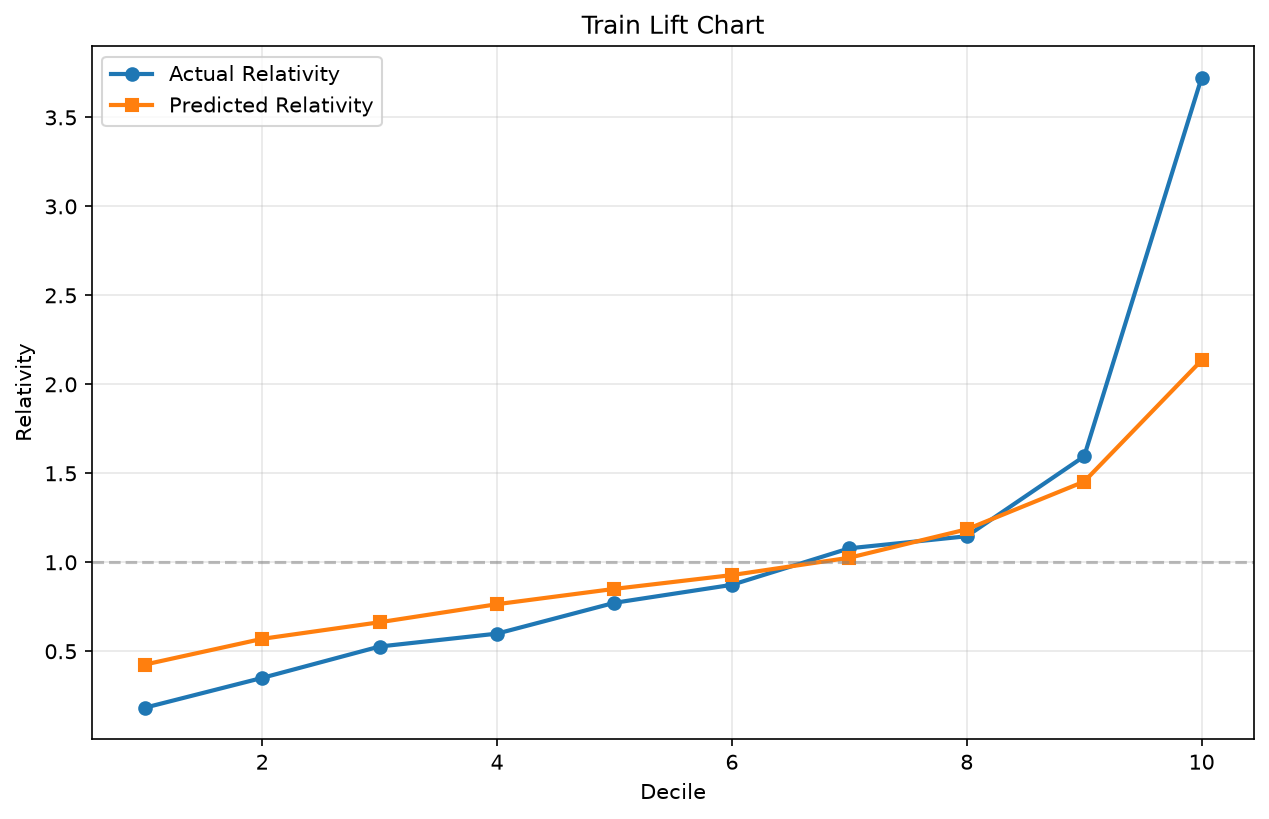


Train decile table:
   decile          act        pred   act_rel  pred_rel
0       1    61.610643  143.460490  0.182560  0.425091
1       2   118.222199  192.284435  0.350307  0.569762
2       3   177.729377  223.772084  0.526634  0.663064
3       4   202.174126  258.001679  0.599066  0.764490
4       5   260.640771  287.046194  0.772310  0.850553
5       6   294.709614  313.215662  0.873260  0.928096
6       7   363.994359  346.113892  1.078559  1.025577
7       8   386.840209  399.960651  1.146254  1.185132
8       9   538.347882  490.503425  1.595190  1.453421
9      10  1256.401679  720.460663  3.722870  2.134812


In [19]:
# Train lift chart


train_chart_file = f"{output_base}/results/05_lift_chart_train.png"
fig_train.savefig(train_chart_file, dpi=150, bbox_inches='tight')
plt.close(fig_train)

print(f"  Saved: {train_chart_file}")

# Display inline in notebook
from IPython.display import Image, display
display(Image(train_chart_file))

print("\nTrain decile table:")
print(table_train[['decile', 'act', 'pred', 'act_rel', 'pred_rel']])


* Generating test lift chart...
  [STEP 1] Creating column list...
  [STEP 1] Done in 0.000s
  [STEP 2] Extracting 5 columns from 2,707,950 rows...
  [STEP 2] Done in 0.028s
  [STEP 3a] Sorting by prediction (this may take 1-2 min for 2.7M rows)...


  [STEP 3a] sort_values done in 0.3s
  [STEP 3b] Resetting index...
  [STEP 3b] Done in 0.000s
  [STEP 4] Calculating cumulative weight...
  [STEP 4] Done in 0.033s
  [STEP 5] Aggregating by decile...
  [STEP 5] Done in 0.134s
  Creating plot...
  Plot created in 0.0s
  TOTAL TIME: 0.5s


  Saved: output/car_coll/v1/results/05_lift_chart_test.png


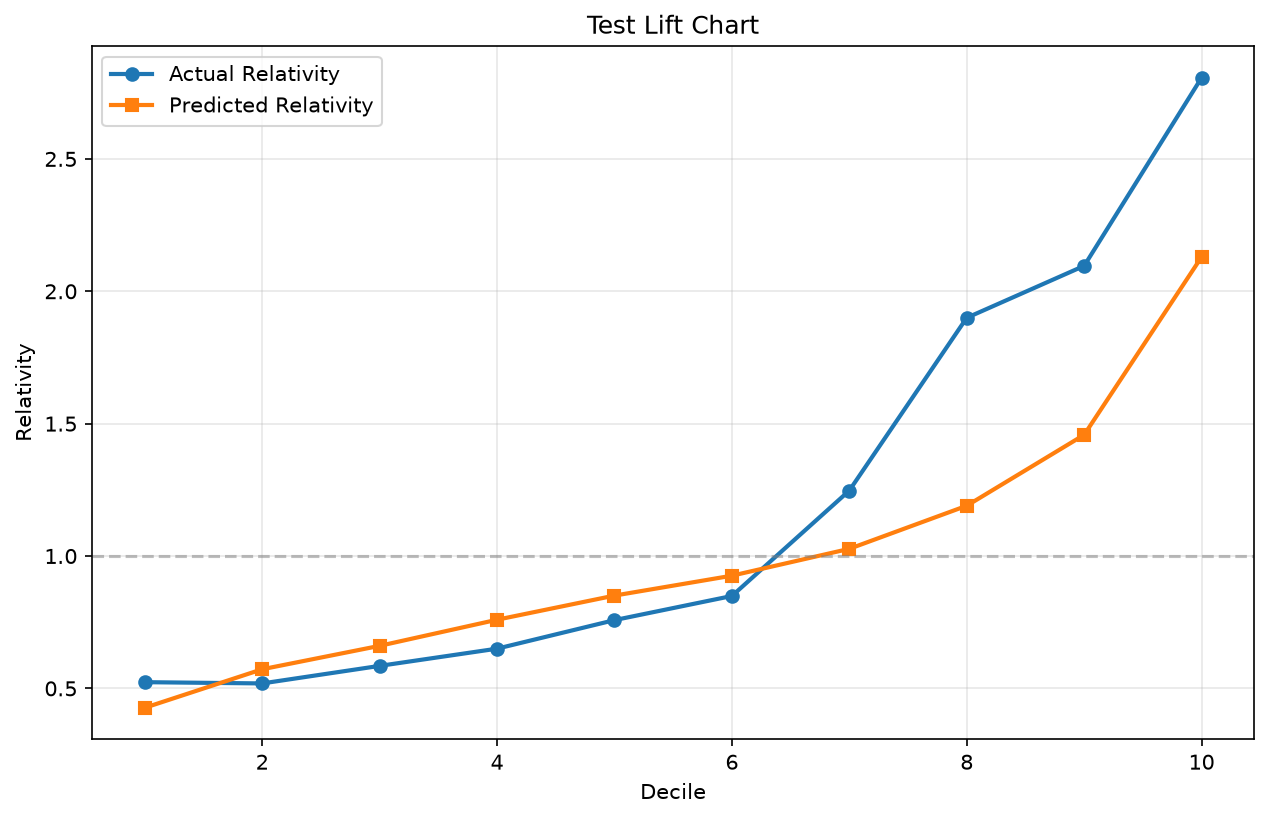


Test decile table:
   decile         act        pred   act_rel  pred_rel
0       1  176.791733  144.166571  0.523524  0.426913
1       2  175.182484  193.259697  0.518759  0.572290
2       3  197.556578  223.128196  0.585014  0.660738
3       4  219.516896  256.421464  0.650044  0.759328
4       5  255.937205  287.225008  0.757894  0.850545
5       6  286.724579  312.610798  0.849063  0.925719
6       7  421.185197  346.869133  1.247235  1.027166
7       8  641.561041  401.824626  1.899822  1.189903
8       9  707.832097  492.290921  2.096068  1.457796
9      10  947.782152  719.155256  2.806620  2.129598


In [20]:
# Test lift chart
print("\n* Generating test lift chart...")
fig_test, table_test = create_lift_chart(test, weight_col, bins=10, title="Test Lift Chart")

test_chart_file = f"{output_base}/results/05_lift_chart_test.png"
fig_test.savefig(test_chart_file, dpi=150, bbox_inches='tight')
plt.close(fig_test)

print(f"  Saved: {test_chart_file}")

# Display inline in notebook
display(Image(test_chart_file))

print("\nTest decile table:")
print(table_test[['decile', 'act', 'pred', 'act_rel', 'pred_rel']])

In [21]:
print("\n########################################")
print("# STAGE 05: COMPLETE")
print("########################################")


########################################
# STAGE 05: COMPLETE
########################################
